In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_56594/4162663930.py:29: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [6]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [7]:
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [8]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [9]:
with open(data_dir+'galaxies_tng300_072_hmc_lensing_prof_types.txt','rb') as f:
    lensing_cat=pickle.load(f)

In [10]:
with open(data_dir+'galaxies_tng300_072_hmc_lensing_prof_types_new.txt','rb') as f:
    lensing_cat_new=pickle.load(f)

In [11]:
lensing_cat_new[100]

{'gas': array([9.72456890e+12, 1.02938361e+13, 1.52953292e+13, 1.70489747e+13,
        1.59673889e+13, 1.33606834e+13, 9.42061000e+12, 5.84053290e+12,
        3.39791449e+12, 2.34223384e+12, 1.84570567e+12, 1.73921265e+12,
        2.01743721e+12, 1.20444473e+12, 7.05107299e+11, 9.65162588e+11,
        4.26684973e+11, 2.98663139e+11, 5.23946892e+11]),
 'dm': array([1.97556349e+14, 2.12274130e+14, 2.05217862e+14, 1.56712957e+14,
        1.21865386e+14, 1.02395218e+14, 6.26139256e+13, 3.92761014e+13,
        2.12918697e+13, 1.25896108e+13, 1.14734676e+13, 1.01193826e+13,
        1.15960743e+13, 6.70948483e+12, 4.09476396e+12, 5.53563138e+12,
        2.43356724e+12, 1.66950935e+12, 2.95270416e+12]),
 'stellar': array([8.47669425e+12, 7.62853139e+12, 8.34478949e+12, 3.87417520e+12,
        2.47332041e+12, 2.09181850e+12, 9.50031037e+11, 5.74254374e+11,
        3.13572049e+11, 1.58106765e+11, 1.64300366e+11, 1.11512172e+11,
        1.18955484e+11, 6.31168754e+10, 4.57520886e+10, 5.86262258e+

In [12]:
lensing_cat[100]

{'gas': array([9.50153167e+12, 1.26012678e+13, 1.63949785e+13, 1.70356765e+13,
        1.55010569e+13, 1.34214883e+13, 9.32494984e+12, 5.86307015e+12,
        3.42831490e+12, 2.31264947e+12, 1.84180150e+12, 1.73824922e+12,
        2.03137535e+12, 1.19958864e+12, 6.95991238e+11, 9.74611733e+11,
        4.25497231e+11, 2.96741501e+11, 5.23230289e+11]),
 'dm': array([1.86282225e+14, 2.08687642e+14, 2.06413431e+14, 1.56098425e+14,
        1.22099592e+14, 1.02800805e+14, 6.24615139e+13, 3.89926218e+13,
        2.14154623e+13, 1.25330570e+13, 1.12423225e+13, 1.00683897e+13,
        1.16226016e+13, 6.70554742e+12, 4.09768421e+12, 5.55140212e+12,
        2.43988639e+12, 1.67028063e+12, 2.95261845e+12]),
 'stellar': array([7.77622426e+12, 6.81186728e+12, 8.21571963e+12, 3.66149721e+12,
        2.47830095e+12, 2.12323433e+12, 9.59922704e+11, 5.91077585e+11,
        3.13712535e+11, 1.59956099e+11, 1.67155631e+11, 1.11265715e+11,
        1.15702426e+11, 6.47798159e+10, 4.55616036e+10, 5.73284890e+

In [13]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [14]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]
def bootstrap_lensing(gal_num_list,name,rp_bins,times=5000,lensing_cat0=lensing_cat):
    lens_list=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        lens_tab=[]
        for i in gal_rand:
            lens_tab.append(lensing_cat0[i][name])
        lens=np.mean(lens_tab,axis=0)
        lens_list.append(lens)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(lens_list).T[j],84))
        lower.append(np.percentile(np.asarray(lens_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

In [15]:
logrp_bins = np.linspace(-1,1.5,20)
rp_bins = 10**logrp_bins
logrp_mids = 0.5*(logrp_bins[:-1] + logrp_bins[1:])

In [16]:
mask1=(tab2['c_200c']<15)

In [17]:
mpeak_hist=[[],]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        print(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

1036
1758
2015
2085
2245
3025
3243


In [18]:
age_tab[mpeak_hist[0][0]]

array([0.37 , 0.418, 0.475, 0.517, 0.547, 0.596, 0.64 , 0.687, 0.732,
       0.764, 0.844, 0.932, 0.965, 1.036, 1.112, 1.177, 1.282, 1.366,
       1.466, 1.54 , 1.689, 1.812, 1.944, 2.145, 2.238, 2.384, 2.539,
       2.685, 2.839, 2.981, 3.129, 3.285, 3.447, 3.593, 3.744, 3.902,
       4.038, 4.206, 4.293, 4.502, 4.657, 4.816, 4.98 , 5.115, 5.289,
       5.431, 5.577, 5.726, 5.878, 6.073, 6.193, 6.356, 6.522, 6.692,
       6.822, 6.998, 7.132, 7.314, 7.453, 7.642, 7.786, 7.932, 8.079,
       8.28 , 8.432, 8.587, 8.743, 8.902, 9.062, 9.225, 9.389])

In [19]:
age_list=age_tab[32:73]*0.9999

In [20]:
def bootstrap_ratio_lensing(gal_num_upp,gal_num_down,name,rp_bins,times=5000,lensing_cat=lensing_cat):
    ratio_list=[]
    for ii in range(times):
        gal_rand_upp=resample_list(gal_num_upp)
        lens_tab=[]
        for i in gal_rand_upp:
            lens_tab.append(lensing_cat[i][name])
        lens_upp=np.mean(lens_tab,axis=0)
        gal_rand_down=resample_list(gal_num_down)
        lens_tab=[]
        for i in gal_rand_down:
            lens_tab.append(lensing_cat[i][name])
        lens_down=np.mean(lens_tab,axis=0)
        ratio_list.append(lens_down/lens_upp)
    upper=[]
    lower=[]
    for j in range(len(rp_bins)-1):
        upper.append(np.percentile(np.asarray(ratio_list).T[j],84))
        lower.append(np.percentile(np.asarray(ratio_list).T[j],16))
    return np.asarray(upper),np.asarray(lower)

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_56594/3450845792.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])


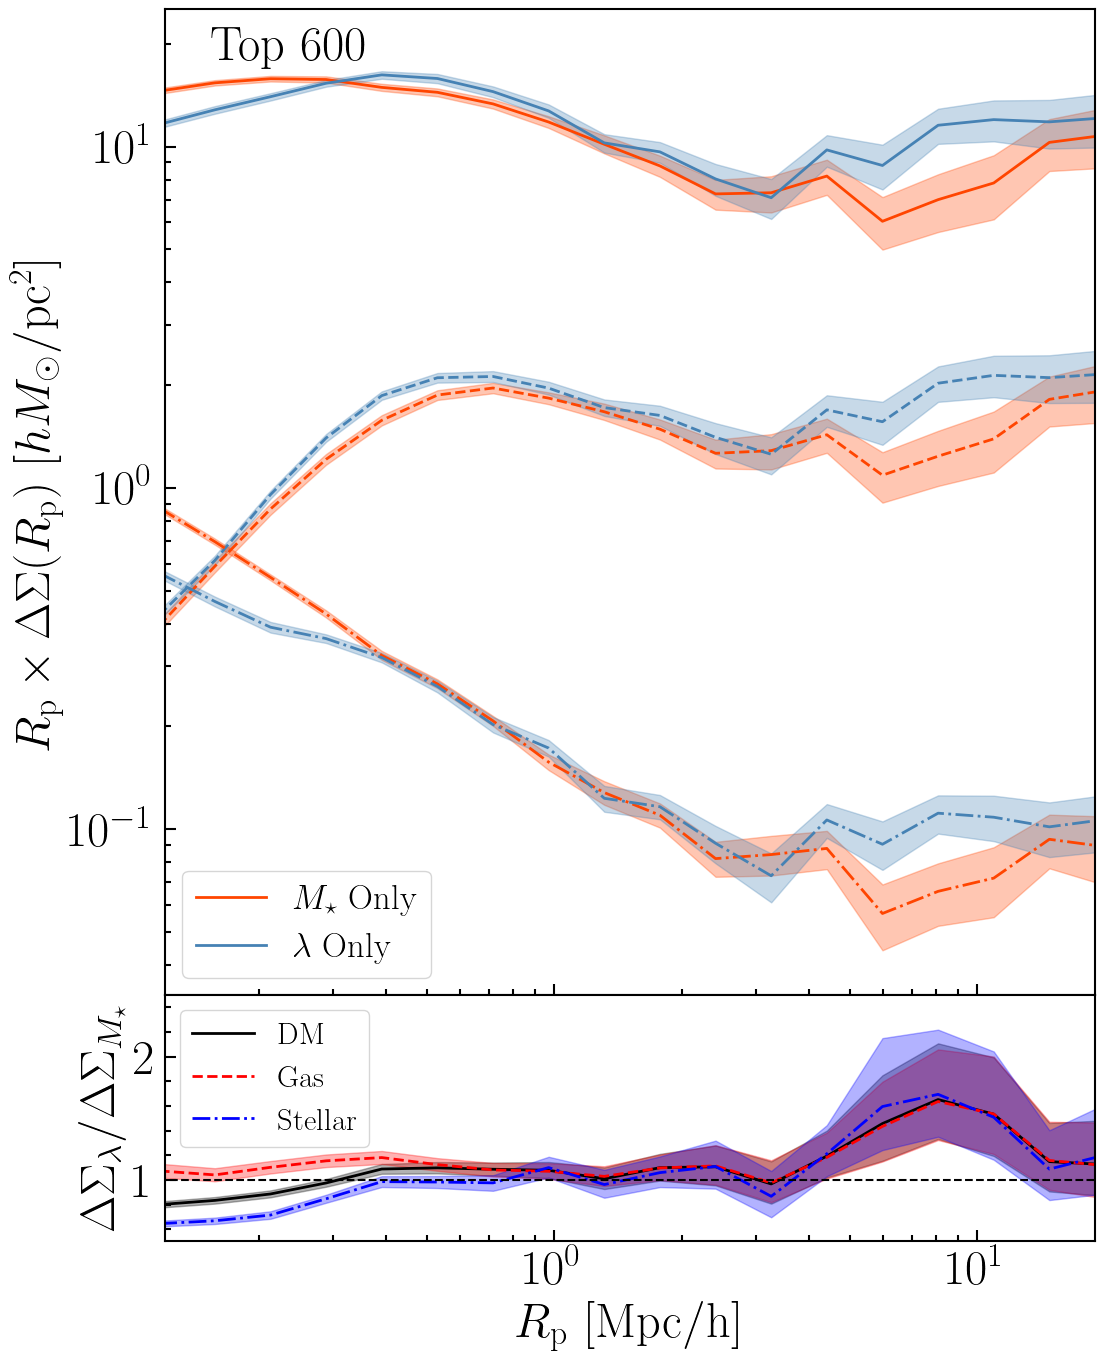

In [21]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=600
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['dm'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'dm',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['dm'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'dm',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'dm',rp_bins)


fig=plt.figure(figsize=(12,16))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0.15,height_ratios=(0.8,0.2))
(ax2,ax3)=gs.subplots(sharex='col')
# ax1 = ax2.inset_axes([0.13, 0.13, 0.22,0.22], transform=ax2.transAxes)
# ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
#             np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
#             c='darkgrey',alpha=0.5)
# ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
# ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

# ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=25)
# ax1.set_xlabel(label,fontsize=25)
ax2.text(0.05,0.95,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=35)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',label=r'$M_\star$ {\rm Only}',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',label=r'$\lambda$ {\rm Only}',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm DM',color='black',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='black',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['gas'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'gas',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['gas'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'gas',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'gas',rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='--',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='--',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Gas',ls='--',color='red',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='red',alpha=0.3)


up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['stellar'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'stellar',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['stellar'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'stellar',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'stellar',rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='-.',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='-.',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Stellar',ls='-.',color='blue',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='blue',alpha=0.3)


ax2.legend(loc=3,fontsize=25)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.12,19)
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax3.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
ax3.set_ylim(0.5,2.5)
ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax3.legend(fontsize=22)


plt.savefig(fig_dir+"FigB1.pdf",dpi=150)

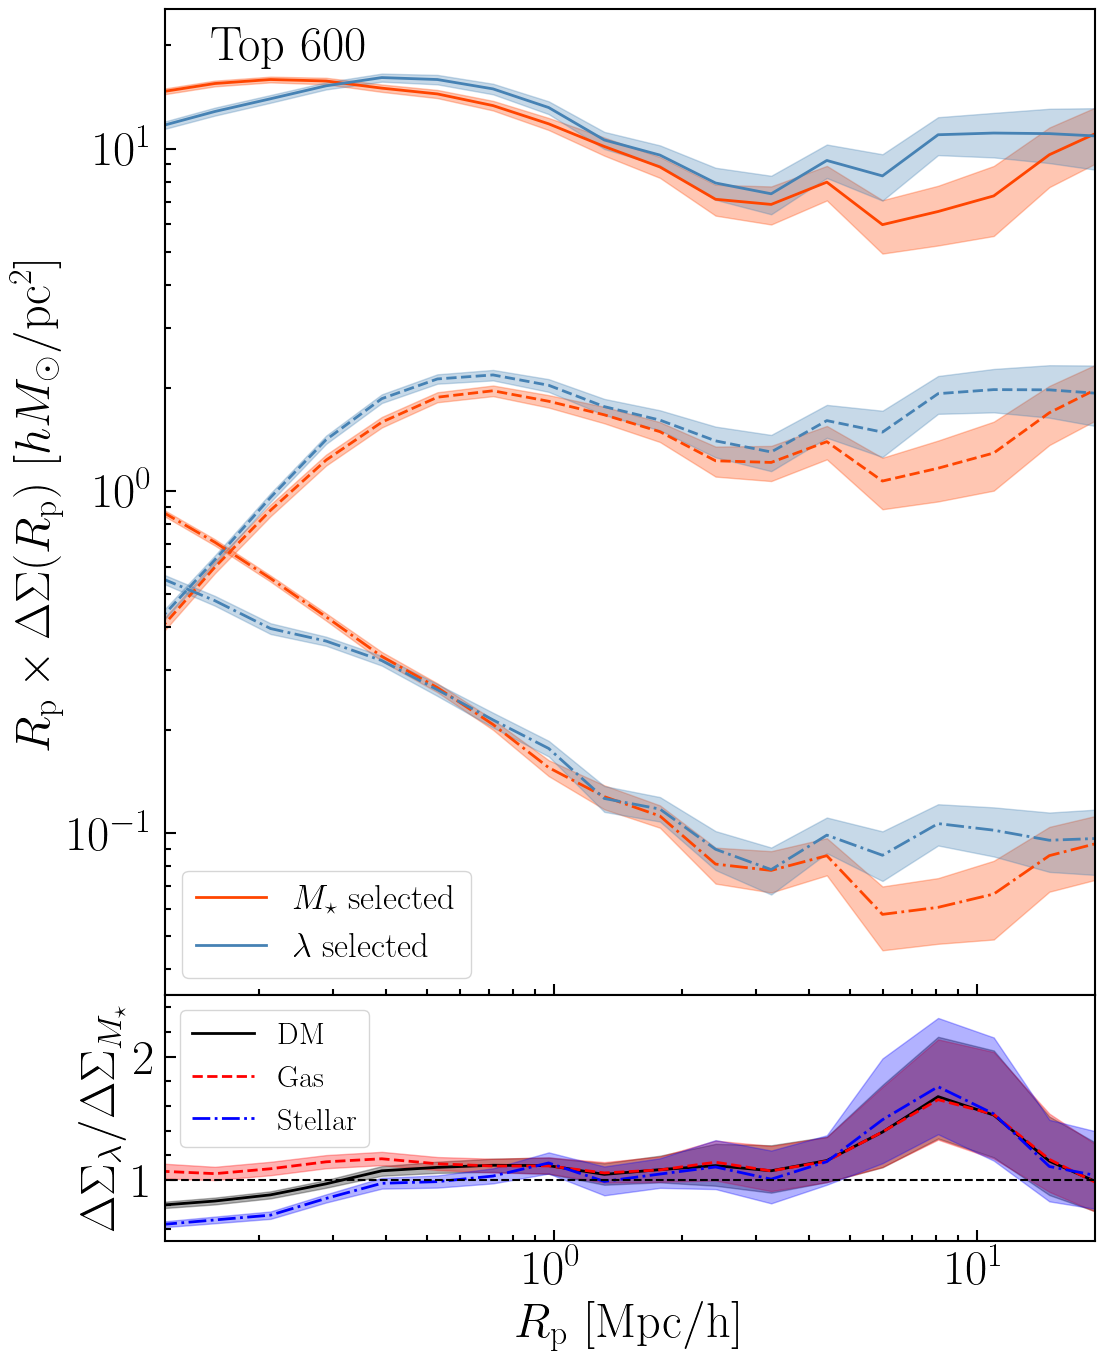

In [ ]:
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_new[i]['dm'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'dm',rp_bins,lensing_cat=lensing_cat_new)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_new[i]['dm'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'dm',rp_bins,lensing_cat=lensing_cat_new)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'dm',rp_bins,lensing_cat=lensing_cat_new)


fig=plt.figure(figsize=(12,16))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0.15,height_ratios=(0.8,0.2)) 
(ax2,ax3)=gs.subplots(sharex='col')
# ax1 = ax2.inset_axes([0.13, 0.13, 0.22,0.22], transform=ax2.transAxes)
# ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
#             np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
#             c='darkgrey',alpha=0.5)
# ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
# ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

# ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=25)
# ax1.set_xlabel(label,fontsize=25)
ax2.text(0.05,0.95,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=35)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',label=r'$M_\star$ {\rm selected}',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',label=r'$\lambda$ {\rm selected}',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm DM',color='black',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='black',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_new[i]['gas'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'gas',rp_bins,lensing_cat=lensing_cat_new)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_new[i]['gas'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'gas',rp_bins,lensing_cat=lensing_cat_new)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'gas',rp_bins,lensing_cat=lensing_cat_new)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='--',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='--',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Gas',ls='--',color='red',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='red',alpha=0.3)


up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat_new[i]['stellar'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'stellar',rp_bins,lensing_cat=lensing_cat_new)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat_new[i]['stellar'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'stellar',rp_bins,lensing_cat=lensing_cat_new)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'stellar',rp_bins,lensing_cat=lensing_cat_new)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='-.',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='-.',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Stellar',ls='-.',color='blue',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='blue',alpha=0.3)


ax2.legend(loc=3,fontsize=25)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.12,19)
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax3.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
ax3.set_ylim(0.5,2.5)
ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax3.legend(fontsize=22)


plt.savefig(fig_dir+"Fig13b.pdf",dpi=150)

In [36]:
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['stellar'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'stellar',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['stellar'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'stellar',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'stellar',rp_bins)

In [37]:
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab_new=[]
for i in up_data_gal_num:
    up_data_lens_tab_new.append(lensing_cat_new[i]['stellar'])
up_data_lens_new=np.mean(up_data_lens_tab_new,axis=0)
up_upp_new,up_low_new=bootstrap_lensing(up_data_gal_num,'stellar',rp_bins,lensing_cat=lensing_cat_new)
down_data_lens_tab_new=[]
for i in down_data_gal_num:
    down_data_lens_tab_new.append(lensing_cat_new[i]['stellar'])
down_data_lens_new=np.mean(down_data_lens_tab_new,axis=0)
down_upp_new,down_low_new=bootstrap_lensing(down_data_gal_num,'stellar',rp_bins,lensing_cat=lensing_cat_new)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'stellar',rp_bins,lensing_cat=lensing_cat_new)

In [38]:
up_data_lens

array([7.49917472e+12, 4.43632347e+12, 2.57279716e+12, 1.47850809e+12,
       8.33616304e+11, 5.02417251e+11, 2.87892236e+11, 1.61736186e+11,
       9.74262694e+10, 6.31673934e+10, 3.33391473e+10, 2.38637343e+10,
       1.94433924e+10, 9.48059410e+09, 7.50540059e+09, 6.03806566e+09,
       5.67630341e+09, 4.66995445e+09, 3.62412109e+09])

In [39]:
up_data_lens_new

array([7.55119759e+12, 4.49264861e+12, 2.60137861e+12, 1.48373167e+12,
       8.40141831e+11, 5.02968635e+11, 2.89902170e+11, 1.60227284e+11,
       9.73365044e+10, 6.31271712e+10, 3.37364713e+10, 2.38811764e+10,
       1.94782041e+10, 9.69370469e+09, 7.50695766e+09, 6.06370058e+09,
       5.79905806e+09, 4.71759744e+09, 3.60511209e+09])

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_47609/2527067651.py:7: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])


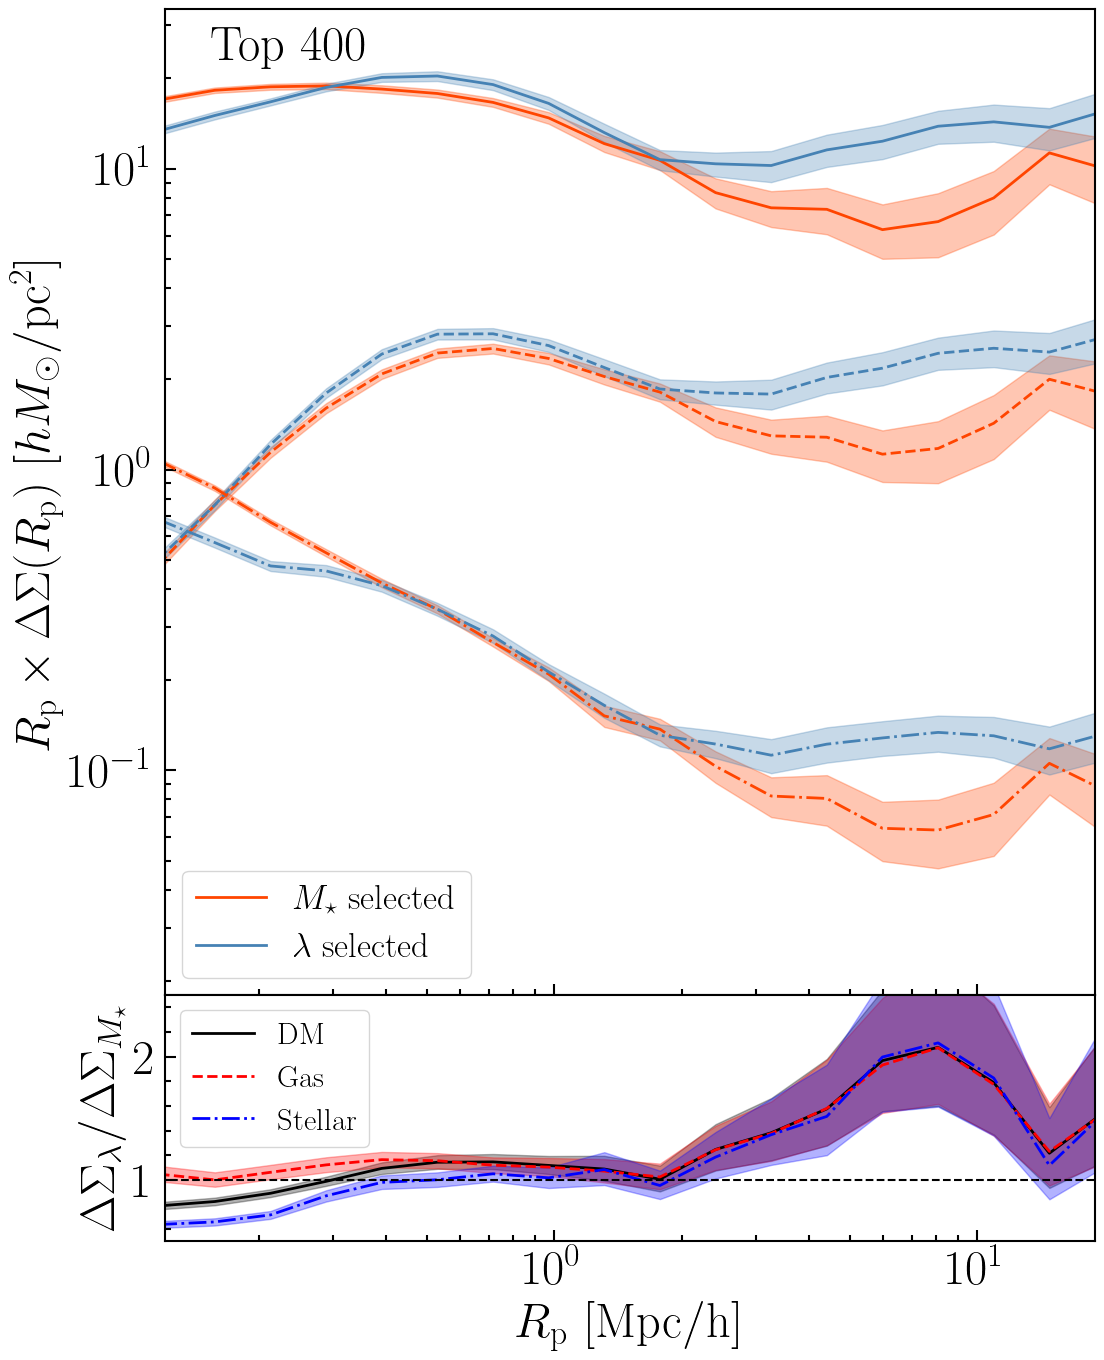

In [18]:
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=400
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l

up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']
up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['dm'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'dm',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['dm'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'dm',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'dm',rp_bins)


fig=plt.figure(figsize=(12,16))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0.15,height_ratios=(0.8,0.2))
(ax2,ax3)=gs.subplots(sharex='col')
# ax1 = ax2.inset_axes([0.13, 0.13, 0.22,0.22], transform=ax2.transAxes)
# ax1.scatter(np.log10(tab2[mask1][(~mask_up)&(~mask_down)][name]),
#             np.log10(tab2[mask1][(~mask_up)&(~mask_down)]['aper_100_gal']-tab2[mask1][(~mask_up)&(~mask_down)]['aper_50_gal']),
#             c='darkgrey',alpha=0.5)
# ax1.scatter(np.log10(up_data[name]),np.log10(up_data['aper_100_gal']-up_data['aper_50_gal']),c='orangered',alpha=0.5)
# ax1.scatter(np.log10(down_data[name]),np.log10(down_data['aper_100_gal']-down_data['aper_50_gal']),c='steelblue',alpha=0.5)

# ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=25)
# ax1.set_xlabel(label,fontsize=25)
ax2.text(0.05,0.95,r'\rm Top %d'%top_numb,transform=ax2.transAxes,fontsize=35)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',label=r'$M_\star$ {\rm selected}',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',label=r'$\lambda$ {\rm selected}',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm DM',color='black',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='black',alpha=0.3)

up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['gas'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'gas',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['gas'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'gas',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'gas',rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='--',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='--',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Gas',ls='--',color='red',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='red',alpha=0.3)


up_data_lens_tab=[]
for i in up_data_gal_num:
    up_data_lens_tab.append(lensing_cat[i]['stellar'])
up_data_lens=np.mean(up_data_lens_tab,axis=0)
up_upp,up_low=bootstrap_lensing(up_data_gal_num,'stellar',rp_bins)
down_data_lens_tab=[]
for i in down_data_gal_num:
    down_data_lens_tab.append(lensing_cat[i]['stellar'])
down_data_lens=np.mean(down_data_lens_tab,axis=0)
down_upp,down_low=bootstrap_lensing(down_data_gal_num,'stellar',rp_bins)
upper,lower=bootstrap_ratio_lensing(up_data_gal_num,down_data_gal_num,'stellar',rp_bins)

__=ax2.plot(10**logrp_mids, 10**logrp_mids*up_data_lens/1e12,color='orangered',ls='-.',lw=2)
__=ax2.plot(10**logrp_mids, 10**logrp_mids*down_data_lens/1e12,color='steelblue',ls='-.',lw=2)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*up_upp/1e12,10**logrp_mids*up_low/1e12,color='orangered',alpha=0.3)
__=ax2.fill_between(10**logrp_mids, 10**logrp_mids*down_upp/1e12,10**logrp_mids*down_low/1e12,color='steelblue',alpha=0.3)
ax3.plot(10**logrp_mids,down_data_lens/up_data_lens,label=r'\rm Stellar',ls='-.',color='blue',lw=2)
ax3.fill_between(10**logrp_mids,upper,lower,color='blue',alpha=0.3)


ax2.legend(loc=3,fontsize=25)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.12,19)
__=ax3.set_xlabel(r'$R_{\rm p} $  $\rm{[Mpc / h]}$', fontsize=35)
__=ax2.set_ylabel(r'$R_{\rm p}\times\Delta\Sigma(R_{\rm p})$  $[h M_{\odot} / {\rm pc}^2]$', fontsize=35)
ax3.set_ylabel(r'$\Delta\Sigma_{\lambda}/\Delta\Sigma_{M_\star}$',fontsize=35)
ax3.set_ylim(0.5,2.5)
ax3.plot(10**logrp_mids,1+0*logrp_mids,ls='--',color='black')
ax3.legend(fontsize=22)
